Cell 1

In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Select device (Mac M-series use 'mps', others 'cpu' or 'cuda')
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"System ready. Running on: {device}")

System ready. Running on: mps


Cell 2: Data Loading and Transformation (Roll No: 102317203)

In [11]:
# Load the dataset from your local folder
df_air = pd.read_csv("data 2.csv", encoding='latin1')

# Cleaning missing NO2 values
no2_data = df_air["no2"].dropna().values.astype(np.float32)

# Transformation logic for Roll No: 102317203
r = 102317203
a_val = 0.5 * (r % 7)      # Result: 1.0
b_val = 0.3 * ((r % 5) + 1) # Result: 1.2

# Formula: z = x + a_r * sin(b_r * x)
z_raw = no2_data + a_val * np.sin(b_val * no2_data)

# Standardization for neural network stability
z_mu, z_sigma = z_raw.mean(), z_raw.std()
z_scaled = (z_raw - z_mu) / z_sigma

# Prepare for PyTorch
z_ref = torch.from_numpy(z_scaled).view(-1, 1).to(device)

print(f"Roll No: {r} | a_r: {a_val} | b_r: {b_val}")
print(f"Dataset Size: {len(z_ref)} samples")

Roll No: 102317203 | a_r: 1.0 | b_r: 1.2
Dataset Size: 419509 samples


/var/folders/z8/d6118hgj3bg8skpbwqk705240000gn/T/ipykernel_62950/3489411934.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_air = pd.read_csv("data 2.csv", encoding='latin1')


Cell 3: GAN Architecture

In [12]:
class GeneratorModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
        self.act = nn.ReLU()

    def forward(self, noise):
        x = self.act(self.fc1(noise))
        x = self.act(self.fc2(x))
        return self.fc3(x)

class DiscriminatorModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_layer = nn.Linear(1, 32)
        self.mid_layer = nn.Linear(32, 32)
        self.out_layer = nn.Linear(32, 1)
        self.lrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, val):
        x = self.lrelu(self.in_layer(val))
        x = self.lrelu(self.mid_layer(x))
        return self.sigmoid(self.out_layer(x))

G = GeneratorModel().to(device)
D = DiscriminatorModel().to(device)

loss_criterion = nn.BCELoss()
# standard Adam settings for GANs
g_optimizer = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

print(G)
print(D)

GeneratorModel(
  (fc1): Linear(in_features=1, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (act): ReLU()
)
DiscriminatorModel(
  (in_layer): Linear(in_features=1, out_features=32, bias=True)
  (mid_layer): Linear(in_features=32, out_features=32, bias=True)
  (out_layer): Linear(in_features=32, out_features=1, bias=True)
  (lrelu): LeakyReLU(negative_slope=0.2)
  (sigmoid): Sigmoid()
)


Cell 4: Training Execution

In [13]:
epochs = 4000
batch_sz = 128
d_losses, g_losses = [], []

for step in range(epochs):
    # --- Step A: Optimize Discriminator ---
    idx = torch.randint(0, z_ref.size(0), (batch_sz,))
    real_v = z_ref[idx]
    
    noise = torch.randn(batch_sz, 1).to(device)
    fake_v = G(noise)
    
    d_real_out = D(real_v)
    d_fake_out = D(fake_v.detach())
    
    loss_real = loss_criterion(d_real_out, torch.ones(batch_sz, 1).to(device))
    loss_fake = loss_criterion(d_fake_out, torch.zeros(batch_sz, 1).to(device))
    
    d_loss = loss_real + loss_fake
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()
    
    # --- Step B: Optimize Generator ---
    g_decision = D(fake_v)
    g_loss = loss_criterion(g_decision, torch.ones(batch_sz, 1).to(device))
    
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()
    
    if step % 1000 == 0:
        print(f"Epoch {step:4d} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch    0 | D Loss: 1.3986 | G Loss: 0.6303
Epoch 1000 | D Loss: 1.3709 | G Loss: 0.7323
Epoch 2000 | D Loss: 1.3877 | G Loss: 0.6921
Epoch 3000 | D Loss: 1.3874 | G Loss: 0.6906


Cell 5: Results and KDE PDF Estimation

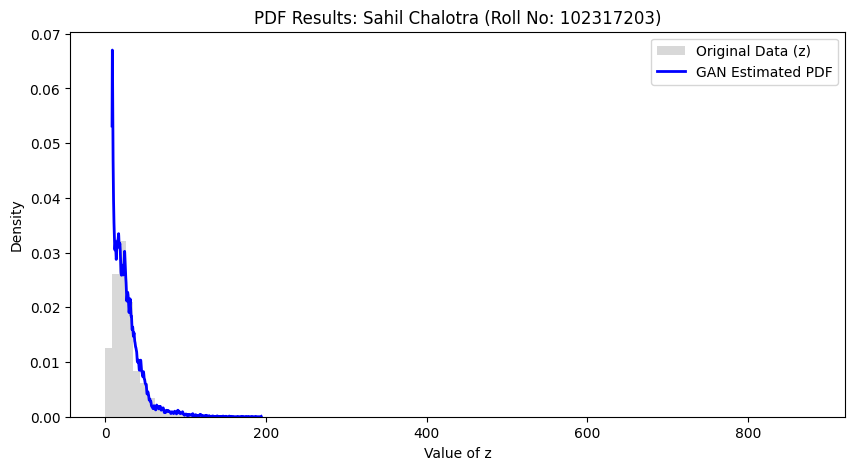

In [14]:
G.eval()
with torch.no_grad():
    gen_noise = torch.randn(15000, 1).to(device)
    raw_gen = G(gen_noise).cpu().numpy()

# Reverse scaling to original NO2 transformed units
z_final = (raw_gen * z_sigma) + z_mu

# Kernel Density Estimation for smooth PDF line
kde_model = KernelDensity(kernel='gaussian', bandwidth=0.4).fit(z_final.reshape(-1, 1))
plot_range = np.linspace(z_final.min(), z_final.max(), 1000).reshape(-1, 1)
log_density = kde_model.score_samples(plot_range)

# Plotting the comparison
plt.figure(figsize=(10, 5))
plt.hist(z_raw, bins=100, density=True, alpha=0.3, color='gray', label='Original Data (z)')
plt.plot(plot_range, np.exp(log_density), color='blue', lw=2, label='GAN Estimated PDF')
plt.title(f"PDF Results: Sahil Chalotra (Roll No: {r})")
plt.xlabel("Value of z")
plt.ylabel("Density")
plt.legend()
plt.show()

A plot showing the grey histogram of the real data and a blue line representing the GAN's learned PDF.